In [1]:
import gensim
from gensim.models import Word2Vec,KeyedVectors

In [4]:
import wget

url = "https://s3.amazonaws.com/dl4j-distribution/GoogleNews-vectors-negative300.bin.gz"
wget.download(url)

HTTPError: HTTP Error 404: Not Found

In [5]:
!curl -L -o GoogleNews-vectors-negative300.bin.gz "https://s3.amazonaws.com/dl4j-distribution/GoogleNews-vectors-negative300.bin.gz"

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
  0      0   0      0   0      0      0      0           00:01              0
100    308   0    308   0      0    159      0           00:01            160
100    308   0    308   0      0    159      0           00:01            160
100    308   0    308   0      0    159      0           00:01            160


In [6]:
!curl -L -o GoogleNews-vectors-negative300.bin.gz https://s3.amazonaws.com/dl4j-distribution/GoogleNews-vectors-negative300.bin.gz

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
  0      0   0      0   0      0      0      0           00:01              0
100    308   0    308   0      0    283      0           00:01            284
100    308   0    308   0      0    283      0           00:01            284
100    308   0    308   0      0    283      0           00:01            284


In [8]:
import gensim.downloader as api

model = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [10]:
!pip install numpy pandas gensim nltk scikit-learn plotly

In [19]:
import os
from nltk import sent_tokenize
from gensim.utils import simple_preprocess

story = []

data_path = 'GOT/data'

for filename in os.listdir(data_path):
    with open(os.path.join(data_path, filename), encoding='latin-1') as f:
        print(filename)
        corpus = f.read()
        
    raw_sent = sent_tokenize(corpus)
    
    for sent in raw_sent:
        story.append(simple_preprocess(sent))

print(len(story))

001ssb.txt
002ssb.txt
003ssb.txt
004ssb.txt
005ssb.txt
145020


In [20]:
model = gensim.models.Word2Vec(
    window=10,
    min_count=2,
    workers=4
)

model.build_vocab(story)

model.train(
    story,
    total_examples=model.corpus_count,
    epochs=model.epochs
)

(6570297, 8628190)

In [22]:
model.wv.most_similar('daenerys')

[('stormborn', 0.8343818187713623),
 ('targaryen', 0.7159734964370728),
 ('princess', 0.7136041522026062),
 ('myrcella', 0.7116471529006958),
 ('queen', 0.7090791463851929),
 ('unburnt', 0.7037901282310486),
 ('moro', 0.6842146515846252),
 ('dorne', 0.6634409427642822),
 ('drogo', 0.6605696678161621),
 ('viserys', 0.6469763517379761)]

In [27]:
model.wv.doesnt_match(['jon','rikon','robb','arya','sansa','bran'])

'jon'

In [28]:
model.wv.doesnt_match(['cersei','jaime','bronn','tyrion'])


'bronn'

In [29]:
model.wv['jon']   # vector

array([-0.9679345 , -0.37461674,  0.5314982 , -1.7360859 ,  1.3330927 ,
        0.31868505,  1.4714046 , -0.07643516, -1.408047  ,  0.60628676,
       -0.11545439, -0.47471544,  0.22598736, -1.8453934 ,  0.2793612 ,
       -0.9528218 ,  0.7178152 ,  2.5802197 , -1.1414391 , -1.062416  ,
        2.511787  , -2.7589545 ,  0.10205757,  0.5407824 ,  0.19224279,
       -0.66211885,  1.6291581 ,  0.6379737 ,  1.4239514 , -0.9483559 ,
       -2.212149  , -1.0654854 , -0.68243515, -1.73755   ,  0.39614514,
       -0.08314524,  1.0638373 , -0.7845005 ,  1.7435801 , -1.50696   ,
       -0.9824661 , -1.4286817 ,  1.7804986 ,  1.5285908 ,  1.1492987 ,
       -2.1627276 , -0.02114373,  0.32292762, -0.65552676, -0.00771732,
       -1.1418924 , -0.9606768 ,  2.0104427 ,  0.5552531 , -0.7451447 ,
        0.4042285 ,  0.68433   , -2.0271473 , -0.09996282, -0.9561823 ,
       -1.1357931 ,  1.6578135 ,  1.9635153 , -1.256272  ,  0.34164244,
       -0.2365005 ,  1.014373  ,  3.6030843 , -0.36163017,  0.29

In [30]:
model.wv['king'].shape

(100,)

In [31]:
model.wv.similarity('arya','sansa')
# model.wv.similarity('cersei','sansa')
# model.wv.similarity('tywin','sansa')

0.85511625

In [32]:
model.wv.similarity('tywin','sansa')

0.23174137

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X = pca.fit_transform(model.wv.get_normed_vectors())

X.shape

(17453, 3)

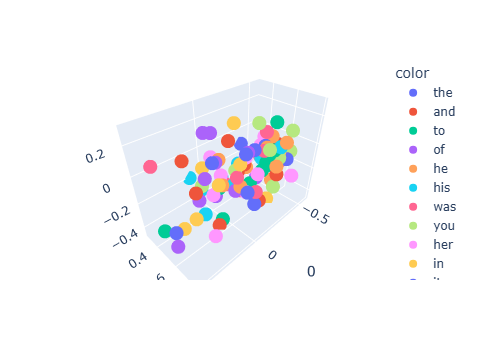

In [35]:
import plotly.express as px

y = model.wv.index_to_key

fig = px.scatter_3d(X[:100], x=0, y=1, z=2, color=y[:100])
fig.show()

In [36]:
model.wv.